In [1]:
#Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

In [2]:
#Load dataset
df = pd.read_csv('Employee attrition.csv')
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [3]:
#Check null values
df.isnull().sum()

Employee ID                 0
Age                         0
Gender                      0
Years at Company            0
Job Role                    0
Monthly Income              0
Work-Life Balance           0
Job Satisfaction            0
Performance Rating          0
Number of Promotions        0
Overtime                    0
Distance from Home          0
Education Level             0
Marital Status              0
Number of Dependents        0
Job Level                   0
Company Size                0
Company Tenure              0
Remote Work                 0
Leadership Opportunities    0
Innovation Opportunities    0
Company Reputation          0
Employee Recognition        0
Attrition                   0
dtype: int64

In [4]:
#Drop unnecessary columns
if 'Employee ID' in df.columns:
    df.drop(columns=['Employee ID'],inplace=True)

In [5]:
df.head()

,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,31,Male,19,Education,5390,Excellent,Medium,Average,2,No,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,59,Female,4,Media,5534,Poor,High,Low,3,No,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,24,Female,10,Healthcare,8159,Good,High,Low,0,No,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,36,Female,7,Education,3989,Good,High,High,1,No,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,56,Male,41,Education,4821,Fair,Very High,Average,0,Yes,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [6]:
#Encode categorical variables
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  label_encoders[col] = le

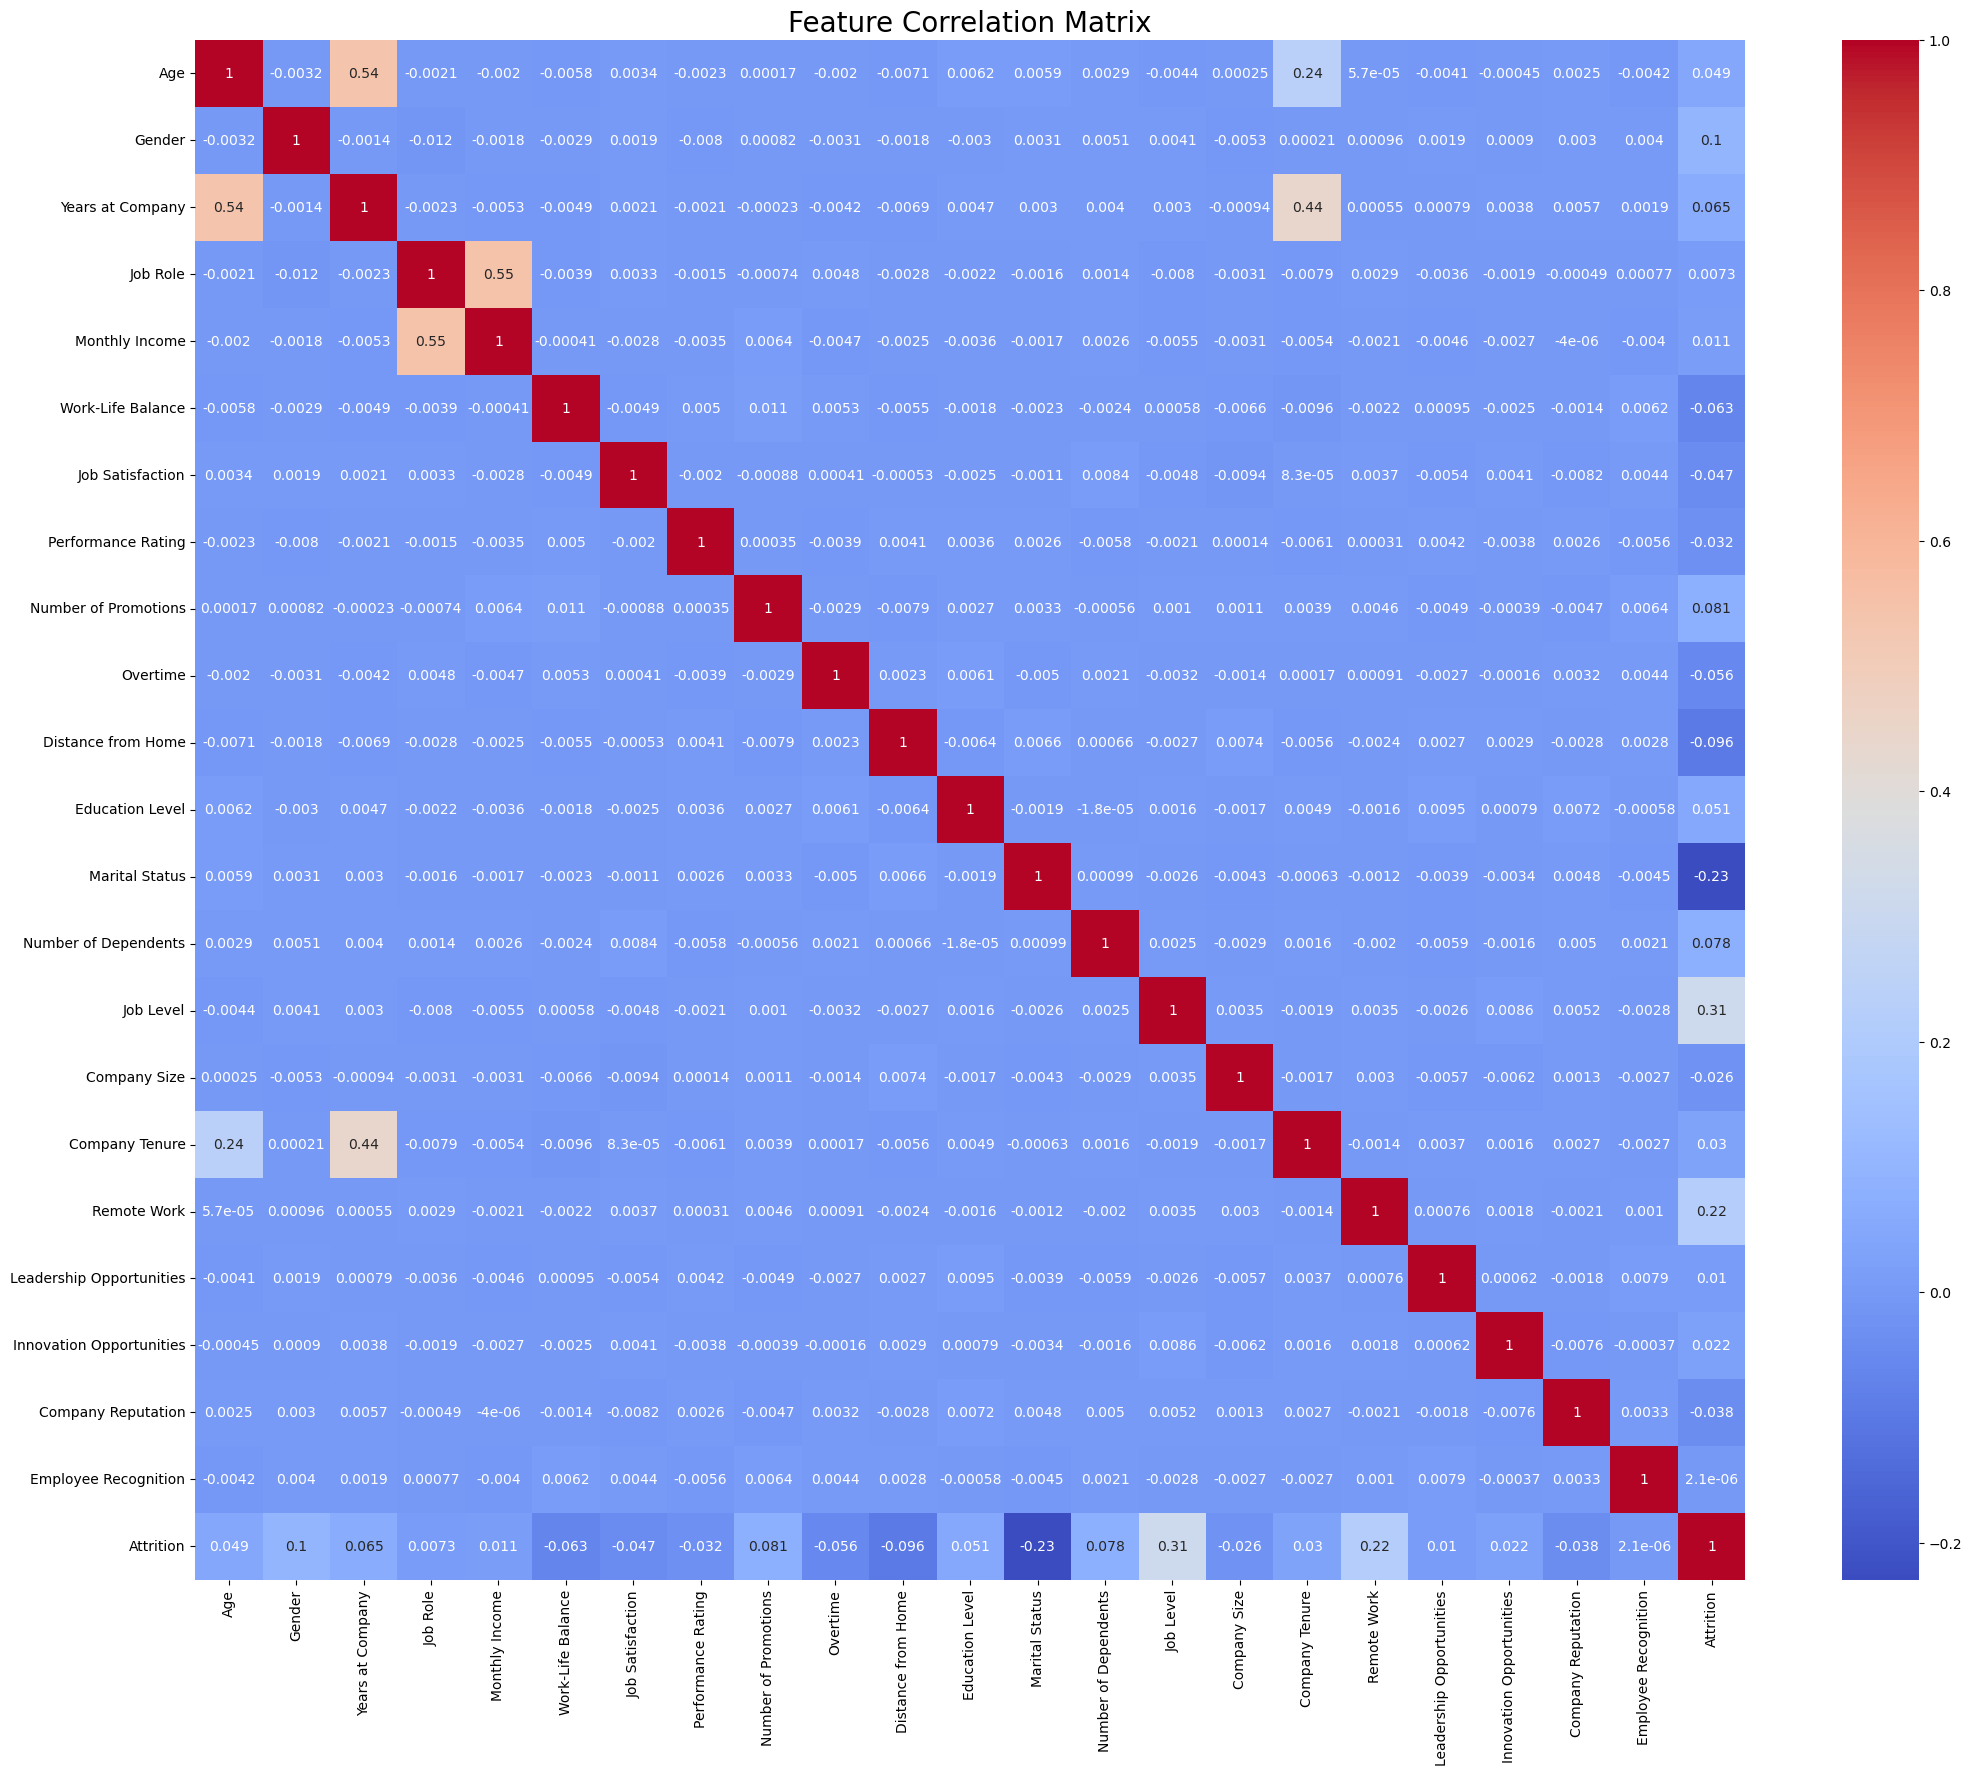

In [7]:
#Heatmap
plt.figure(figsize=(25,20))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix', fontsize=20)
plt.show()

In [9]:
#Define features (X) and target (y)
X = df.drop(columns=['Attrition']) #'Attrition' is the target column
y = df['Attrition']

In [10]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X,y)

print("Before:", y.value_counts())
print("After:", y_resampled.value_counts())

Before: Attrition
1    31260
0    28338
Name: count, dtype: int64
After: Attrition
1    31260
0    31260
Name: count, dtype: int64


In [11]:
#Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                   random_state=42,
                                                   stratify=y)
#Standardize numerical features (optional, but improves performance)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[50,100],
    'max_depth':[5,10, None]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=3)
grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 10, None], 'n_estimators': [50, 100]})

In [13]:
#Get the best parameters
best_params = grid.best_params_
print(f"Best Hyperparameters : {best_params}")

#Train Random Forest with Best hyperparameters
best_rf = RandomForestClassifier(**best_params, random_state=42)
best_rf.fit(X_train, y_train)

Best Hyperparameters : {'max_depth': 10, 'n_estimators': 100}


RandomForestClassifier(max_depth=10, random_state=42)

              precision    recall  f1-score   support

           0       0.73      0.73      0.73      5668
           1       0.76      0.76      0.76      6252

    accuracy                           0.75     11920
   macro avg       0.75      0.75      0.75     11920
weighted avg       0.75      0.75      0.75     11920



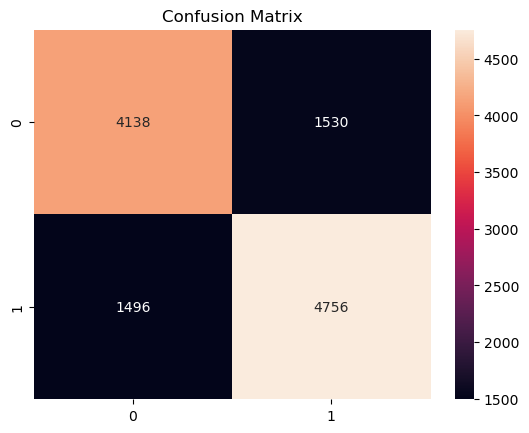

In [14]:
y_pred = best_rf.predict(X_test)

print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

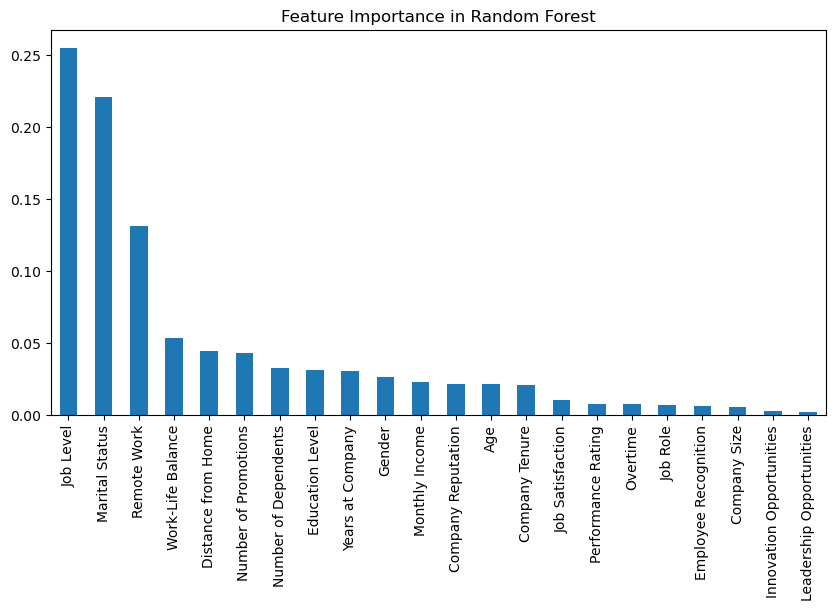

In [16]:
#Feature importance visualization
feature_importances = pd.Series(best_rf.feature_importances_, index = df.drop(columns=['Attrition']).columns)
feature_importances.sort_values(ascending=False).plot(kind="bar", figsize=(10, 5), title="Feature Importance in Random Forest")
plt.show()

In [18]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

In [24]:
#AdaBoostClassifier
adaboost = AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42)
adaboost.fit(X_train, y_train)

#Gradient Boosting Classifier
gradboost = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
gradboost.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [25]:
#Evaluation
models = {
    "Random Forest" : best_rf,
    "AdaBoost" : adaboost,
    "Gradient Boosting" : gradboost
}

for name, model in models.items():
    print(f"\n{name} Performance:")
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report: \n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Random Forest Performance:
Accuracy: 0.7461
Classification Report: 
               precision    recall  f1-score   support

           0       0.73      0.73      0.73      5668
           1       0.76      0.76      0.76      6252

    accuracy                           0.75     11920
   macro avg       0.75      0.75      0.75     11920
weighted avg       0.75      0.75      0.75     11920

Confusion Matrix:
 [[4138 1530]
 [1496 4756]]

AdaBoost Performance:
Accuracy: 0.7483
Classification Report: 
               precision    recall  f1-score   support

           0       0.73      0.74      0.74      5668
           1       0.76      0.76      0.76      6252

    accuracy                           0.75     11920
   macro avg       0.75      0.75      0.75     11920
weighted avg       0.75      0.75      0.75     11920

Confusion Matrix:
 [[4185 1483]
 [1517 4735]]

Gradient Boosting Performance:
Accuracy: 0.7565
Classification Report: 
               precision    recall  f1-score  

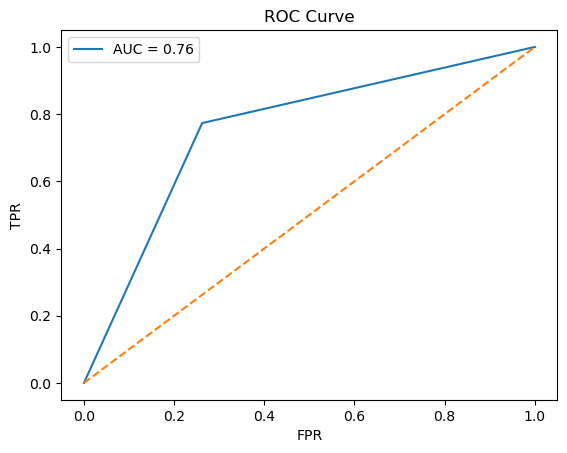

In [26]:
fpr,tpr, _ = roc_curve(y_test, y_p)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()